Group name: Stock Success
Created by Lexinejazly Asuncion (017077242), Pranavi Immanni (017207554), Anika Manjesh (017808479)

In [33]:
!pip install pandas seaborn matplotlib scikit-learn hvplot


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [34]:
#datframes and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#data preprocessing for ML
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#ML models and evaluation
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

## **Import Data and Clean**

In [35]:
# Tech
apple_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/apple.csv'
nvidia_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/nvidia.csv'
microsoft_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/microsoft.csv'

# Defense
lockheed_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/lockheedmartin.csv'
northrop_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/northropgrumman.csv'
boeing_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/boeing.csv.zip'

# Waste Management
waste_mgt_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wastemanagementinc.csv'
republic_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/republicservices.csv'
waste_conn_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wasteconnections.csv'

In [36]:
url_list = {
    'AAPL': apple_url,
    'NVDA': nvidia_url,
    'MSFT': microsoft_url,
    'LMT': lockheed_url,
    'NOC': northrop_url,
    'BA': boeing_url,
    'WM': waste_mgt_url,
    'RSG': republic_url,
    'WCN': waste_conn_url
}

all_frames = []

rename_map = {
    'date': 'Date',
    'price': 'Close',
    'Price': 'Close',
    'Close/Last': 'Close',
    'close': 'Close',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'volume': 'Volume',
    'Vol.': 'Volume',
    'adj_close': 'Adj Close'
}

tech_tickers = ['AAPL', 'NVDA', 'MSFT']
defense_tickers = ['LMT', 'NOC', 'BA']
waste_tickers = ['WM', 'RSG', 'WCN']

#read csv files and store data into one dataframe
for name, url in url_list.items():
    df = pd.read_csv(url,
                     na_values=["-", ""])

    df.columns = [col.strip() for col in df.columns]

    df = df.rename(columns=rename_map)
    
    df['Ticker'] = name

    #create column 'Industry' that specifies the industry
    if name in tech_tickers:
        df['Industry'] = 'Tech'
    elif name in defense_tickers:
        df['Industry'] = 'Defense'
    elif name in waste_tickers:
        df['Industry'] = 'Waste Management'

    #keep only the columns that exist in almost all sets
    standard_cols = ['Industry', 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[standard_cols]

    all_frames.append(df)

#merge the dataframes into one
stocks = pd.concat(all_frames, ignore_index=True)
stocks['Date'] = pd.to_datetime(stocks['Date'], format='mixed', utc=True).dt.tz_localize(None)

In [37]:
#clean 'Volume', 'Open', 'High', 'Low', and 'Close' columns
stocks['Volume'] = pd.to_numeric(stocks['Volume'].astype(str).str.replace('M', 'e6').str.replace('K', 'e3').str.replace('B', 'e9'), errors='coerce')

numeric_cols = ['Open', 'High', 'Low', 'Close']

for col in numeric_cols:
    stocks[col] = pd.to_numeric(
        stocks[col].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')
     

In [38]:
stocks.head()

,Industry,Date,Ticker,Open,High,Low,Close,Volume
0,Tech,2025-09-26,AAPL,254.10,257.60,253.78,255.46,46080000.0
1,Tech,2025-09-25,AAPL,253.21,257.17,251.71,256.87,55200000.0
2,Tech,2025-09-24,AAPL,255.22,255.74,251.04,252.31,42300000.0
3,Tech,2025-09-23,AAPL,255.88,257.34,253.58,254.43,60280000.0
4,Tech,2025-09-22,AAPL,248.30,256.64,248.12,256.08,105520000.0


In [39]:
stocks.describe()

,Date,Open,High,Low,Close,Volume
count,53011,53011.000000,53011.000000,53011.000000,53011.000000,5.301000e+04
mean,2007-06-15 15:51:36.308313,91.936971,92.837901,91.026213,91.950703,1.187463e+08
min,1962-01-02 00:00:00,0.060833,0.065667,0.060000,0.061417,7.290000e+04
25%,2000-03-13 02:30:00,5.664032,5.728395,5.574074,5.656250,1.366203e+06
50%,2011-11-09 05:00:00,43.920000,44.437500,43.312500,43.937500,3.732000e+06
75%,2019-08-28 00:00:00,131.250000,132.430000,129.762500,131.135002,6.825630e+07
max,2026-03-27 00:00:00,768.850000,774.000000,751.870000,768.020000,9.230856e+09
std,NaN,118.605668,119.735844,117.456046,118.614944,2.814343e+08


In [40]:
stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 53011 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Industry  53011 non-null  str           
 1   Date      53011 non-null  datetime64[us]
 2   Ticker    53011 non-null  str           
 3   Open      53011 non-null  float64       
 4   High      53011 non-null  float64       
 5   Low       53011 non-null  float64       
 6   Close     53011 non-null  float64       
 7   Volume    53010 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(2)
memory usage: 3.2 MB


There is missing data for one data entry in the stocks dataframe that corresponds to the Volume column. Since there is only one missing data point, we can remove it.

In [41]:
stocks.dropna(inplace=True)

In [42]:
stocks.info()

<class 'pandas.DataFrame'>
Index: 53010 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Industry  53010 non-null  str           
 1   Date      53010 non-null  datetime64[us]
 2   Ticker    53010 non-null  str           
 3   Open      53010 non-null  float64       
 4   High      53010 non-null  float64       
 5   Low       53010 non-null  float64       
 6   Close     53010 non-null  float64       
 7   Volume    53010 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(2)
memory usage: 3.6 MB


## **Exploratory Data Analysis**

**Question 1**: What are the pairwise relationships and distributions between the core numeric features (Open, High, Low, Close, Volume)?

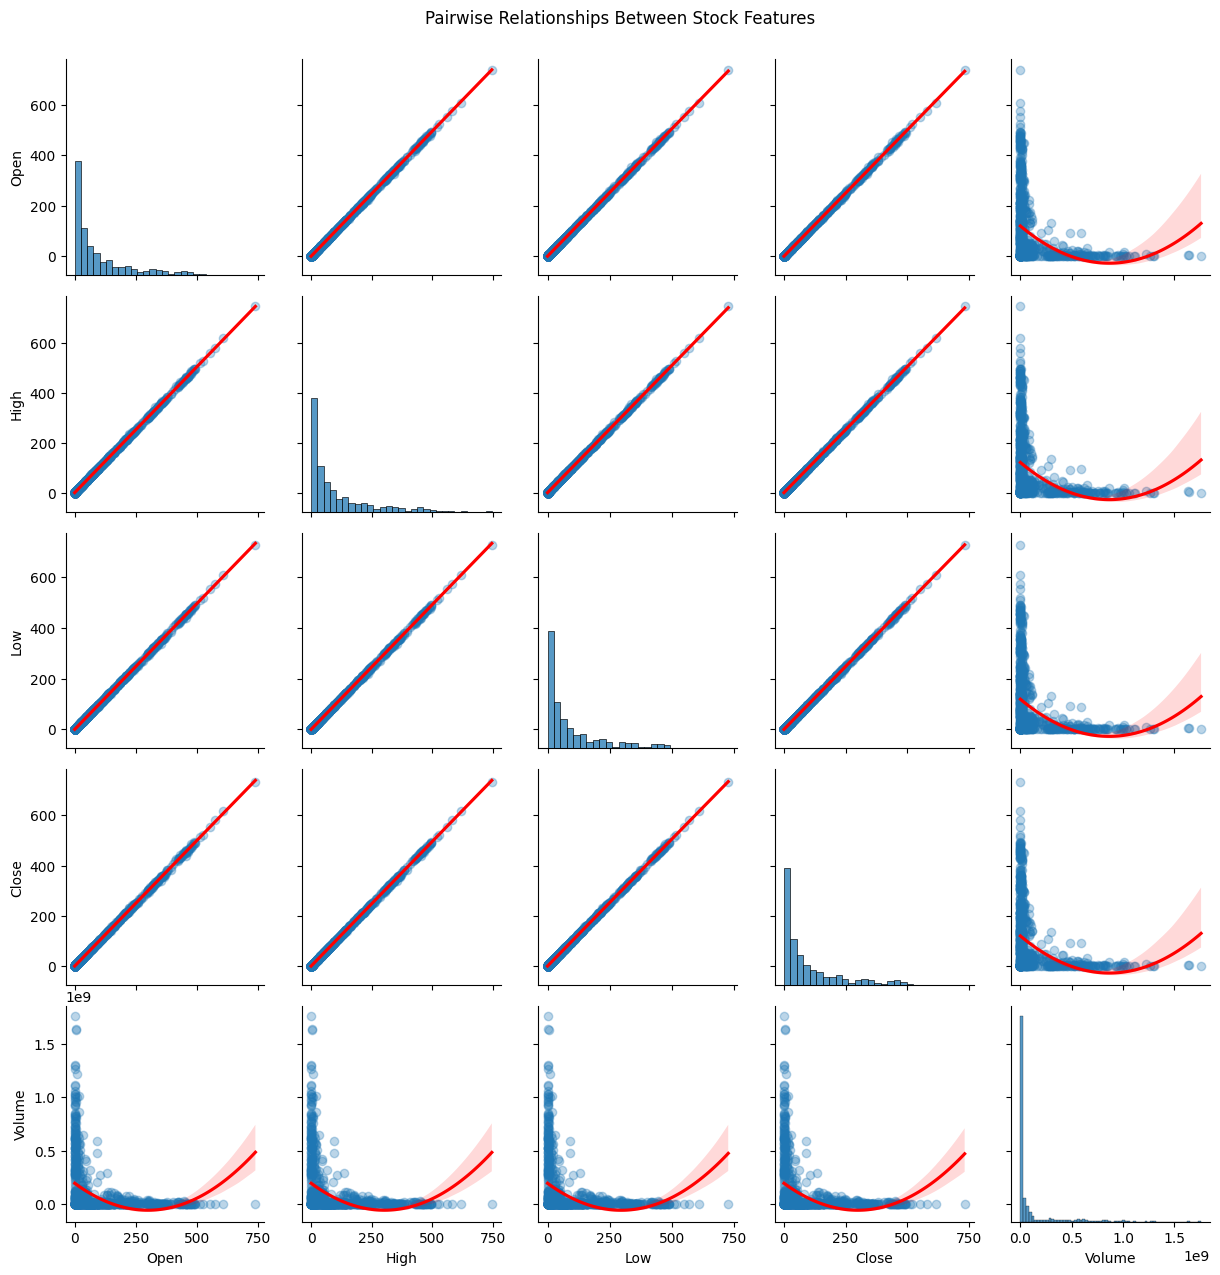

In [43]:
sample_stocks = stocks[['Open', 'High', 'Low', 'Close', 'Volume']].sample(1000, random_state=42)

g = sns.PairGrid(sample_stocks)
g.map_diag(sns.histplot)
g.map_offdiag(
    sns.regplot,
    order=2,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

g.fig.suptitle("Pairwise Relationships Between Stock Features", y=1.02)
plt.show()

The pair plots reveal an extremely high linear correlation between the price-based features (Open, High, Low, and Close). The regression lines (red) are nearly straight, indicating that these values move almost perfectly in sync. However, the relationship between Price and Volume is non-linear; the polynomial regression shows that the highest trading volumes often occur at lower price points or during specific volatility spikes, rather than increasing steadily as the stock price rises.

**Question 2**: How do open and close prices relate across different industries?

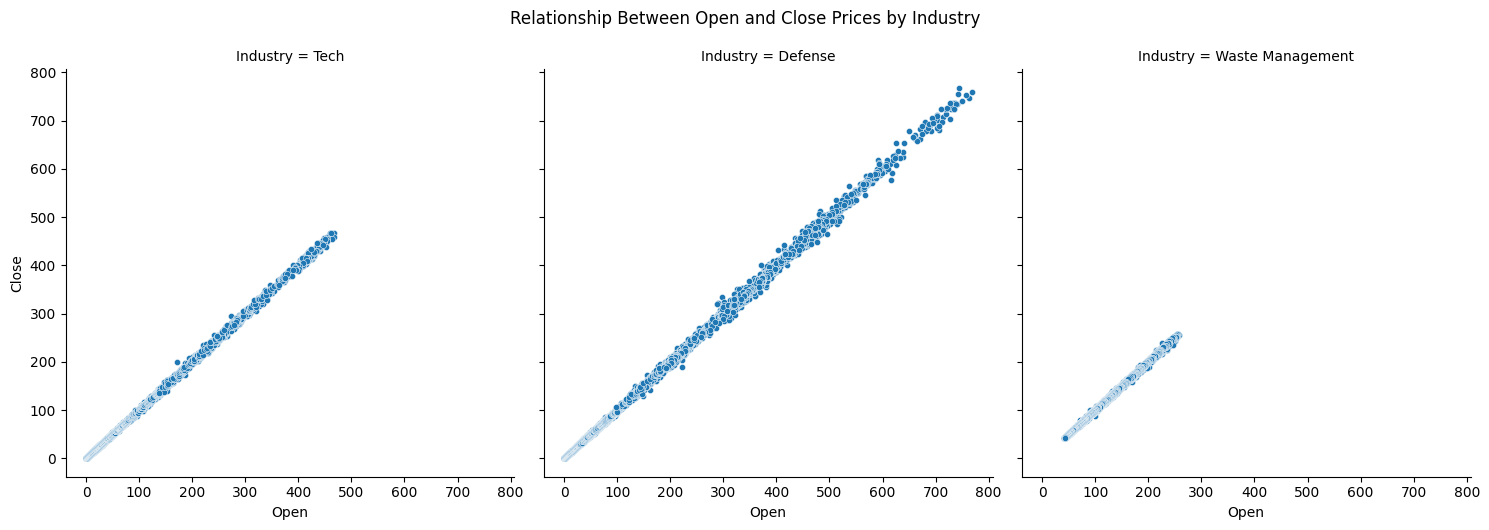

In [44]:
g = sns.relplot(
    data=stocks,
    x="Open",
    y="Close",
    col="Industry",
    col_wrap=3,
    kind="scatter",
    height=5,
    s=20
)

g.fig.suptitle("Relationship Between Open and Close Prices by Industry", y=1.05)

plt.show()

The relplots show that the Tech industry (AAPL, NVDA, MSFT) exhibits much higher price scaling and variance compared to Defense and Waste Management. While all three industries show a tight 1:1 relationship between Open and Close prices, the Tech industry plot has a much larger spread, reflecting its higher historical growth and daily price volatility. Waste Management shows the most "stable" and tightly clustered distribution, indicating less dramatic daily price swings.

**Question 3**: Markets fluctuate a lot every day. Which days are bull markets (increase in value) and which days are bear markets (decrease in value)?

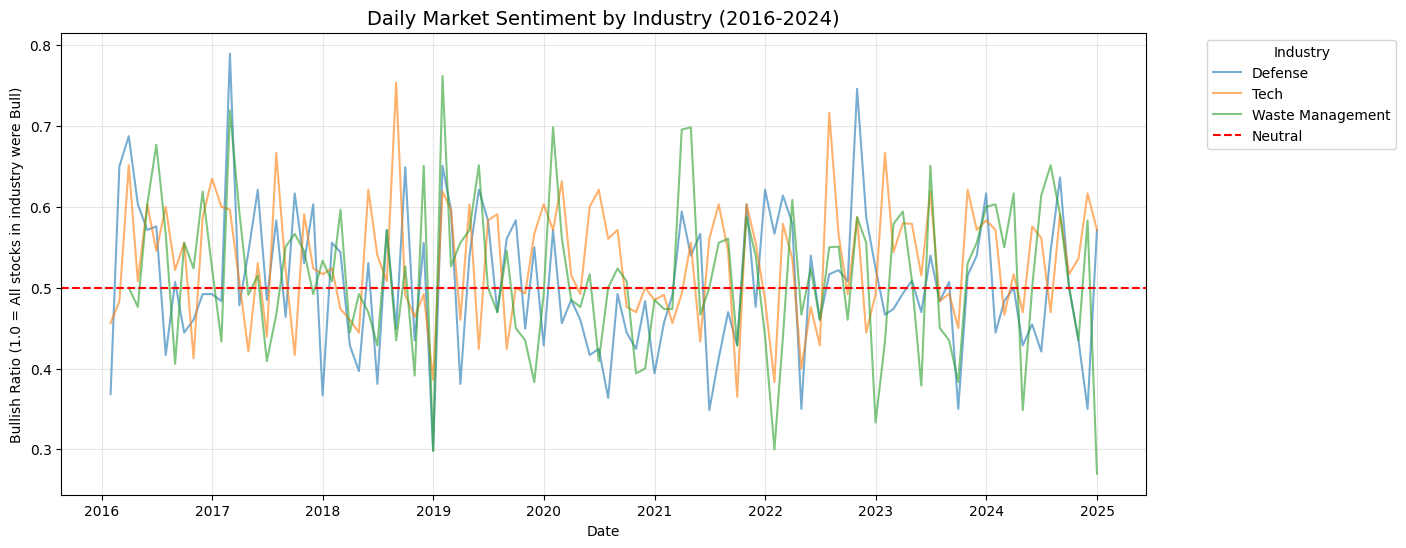

In [45]:
stocks['Market'] = stocks.apply(lambda row: "bull" if (row['Close'] - row['Open']) > 0 else "bear", axis =1)

df_plot = stocks[(stocks['Date'].dt.year >= 2016) & (stocks['Date'].dt.year <= 2024)].copy()

df_plot['is_bull'] = (df_plot['Market'] == 'bull').astype(int)

monthly_sentiment = df_plot.groupby([pd.Grouper(key='Date', freq='ME'), 'Industry'])['is_bull'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sentiment, x='Date', y='is_bull', hue='Industry', alpha=0.6)

plt.title('Daily Market Sentiment by Industry (2016-2024)', fontsize=14)
plt.ylabel('Bullish Ratio (1.0 = All stocks in industry were Bull)')
plt.axhline(0.5, color='red', linestyle='--', label='Neutral')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

The line plot demonstrates that all three industries generally hover around the 0.5 neutral line, meaning daily gains and losses are roughly balanced over the long term. However, significant "dips" below the neutral line are visible across all industries during the 2020 COVID-19 crash, where bearish sentiment dominated. The Tech industry frequently shows higher peaks above the neutral line, suggesting it has more sustained "Bullish" periods compared to the more cyclical Defense and Waste Management sectors.

## **Interactive Plots**

In [46]:
#interactive plots
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from datetime import datetime
from panel.interact import interact

**Question 4**: How does the high price of a specific stock compare against the industry average over time?

In [47]:
import hvplot.pandas as hvplot
import panel as pn
pn.extension()

In [48]:
stocks['Year'] = stocks['Date'].dt.year
stocks['Month'] = stocks['Date'].dt.month

# Select overlapping years
filtered_stocks = stocks[(stocks['Year'] >= 2016) & (stocks['Year'] <= 2024)]

# Calculate monthly highs for each stock/ticker
ticker_highs = filtered_stocks.groupby(['Year', 'Month', 'Industry', 'Ticker'])['High'].max().reset_index()

# Calculate industry average monthly highs
industry_highs = filtered_stocks.groupby(['Year', 'Month', 'Industry'])['High'].mean().reset_index()
industry_highs = industry_highs.rename(columns={'High': 'Avg_High'})

# Merge with ticker highs
combined_df = pd.merge(
    ticker_highs,
    industry_highs,
    on=['Year', 'Month', 'Industry'],
    how='left'
)

# Radio buttons for each industry
industry_radio = pn.widgets.RadioButtonGroup(
    name='Select Industry',
    options=sorted(list(ticker_highs['Industry'].unique())),
    button_type='success'
)

year_slider = pn.widgets.IntSlider(
    name='Select Year',
    start=2016, end=2024, value=2024
)

interactive_highs = combined_df.interactive()

ticker_plot = interactive_highs[
    (interactive_highs['Industry'] == industry_radio) &
    (interactive_highs['Year'] == year_slider)
].sort_values('Month').hvplot(
    x='Month',
    y='High',
    by='Ticker',
    line_width=3,
    marker='o',
    ylabel='High Price (USD)',
    title="Monthly High Price for Individual Stocks vs. Industry Average by Industry",
    width=800,
    height=400,
    grid=True
)

# Industry average line
avg_plot = interactive_highs[
    (interactive_highs['Industry'] == industry_radio) &
    (interactive_highs['Year'] == year_slider)
].sort_values('Month').hvplot(
    x='Month',
    y='Avg_High',
    line_width=3,
    line_dash='dashed',
    color='black',
    label='Industry Avg',
    ylabel='High Price (USD)',
    width=800,
    height=400,
)

# Overlay both plots
stocks_pipeline_plot = (ticker_plot * avg_plot)
stocks_pipeline_plot

From the interactive plot, it is evident that certain "leader" stocks consistently trade above the dashed black Industry Average line. For example, in the Tech sector, NVDA and MSFT often pull the industry average upward, while smaller-cap stocks stay below it. The visualization shows that while stocks within an industry generally follow the same seasonal trends, the "gap" between individual performers and the average widens significantly during high-growth years like 2023.

**Question 5**: Over the years, which industries have shown the highest patterns of market volatility?

In [49]:
stocks['Year'] = stocks['Date'].dt.year
stocks['Month'] = stocks['Date'].dt.month

#select years 2016-2024 where all datasets overlap
filtered_stocks = stocks[(stocks['Year'] >= 2016) & (stocks['Year'] <= 2024)]

monthly_stats = filtered_stocks.groupby(['Year', 'Month', 'Industry']).agg(
    Volatility=('Close', 'std'),
    High_Price=('High', 'max'),
    Low_Price=('Low', 'min'),
    Avg_Close=('Close', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()


year_slider = pn.widgets.IntSlider(
    name='Select Year',
    start=filtered_stocks['Year'].min(),
    end=filtered_stocks['Year'].max(),
    value=2024
)

interactive_volatility = monthly_stats.interactive()

stocks_pipeline_plot = interactive_volatility[
    interactive_volatility['Year'] == year_slider
].hvplot(
    x='Month',
    y="Volatility",
    by='Industry',
    line_width=3,
    xlim=(1, 12),
    ylim=(0, (monthly_stats['Volatility'].max()) * 1.1),
    hover_cols=['High_Price', 'Low_Price', 'Avg_Close', 'Total_Volume'],
    title="Monthly Stock Volatility by Industry",
    width=800,
    height=400,
    grid=True
)

stocks_pipeline_plot

The interactive plot identifies Tech as the most volatile industry by a significant margin, with its standard deviation often doubling that of the other sectors. Waste Management consistently shows the lowest volatility (the flattest line), marking it as the "safest" industry in the dataset. A notable spike in volatility across all industries is visible in early 2020, representing the market's reaction to global economic uncertainty during the start of the pandemic.

# **Machine Learning**

### **Feature Engingeering**

In [50]:
def engineer_features(df):
    df = df.sort_values(['Ticker', 'Date']).copy()
    g = df.groupby('Ticker')['Close']

    # Returns
    df['Return_1D']  = g.pct_change(1)
    df['Return_5D']  = g.pct_change(5)
    df['Return_20D'] = g.pct_change(20)
    df['Return_60D'] = g.pct_change(60)

    # Moving averages
    roll = lambda x, n: x.rolling(n).mean()
    df['MA_20']  = g.transform(roll, 20)
    df['MA_50']  = g.transform(roll, 50)
    df['MA_200'] = g.transform(roll, 200)
    df['Price_to_MA50'] = df['Close'] / df['MA_50']
    df['MA50_to_MA200'] = df['MA_50'] / df['MA_200']

    # Volatility
    ret_g = df.groupby('Ticker')['Return_1D']
    df['Volatility_20D'] = ret_g.transform(lambda x: x.rolling(20).std())
    df['Volatility_60D'] = ret_g.transform(lambda x: x.rolling(60).std())

    # Volume ratio
    vol_ma = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
    df['Volume_Ratio'] = df['Volume'] / vol_ma

    # RSI (14-day)
    def rsi(series, n=14):
        d = series.diff()
        gain = d.clip(lower=0).rolling(n).mean()
        loss = (-d.clip(upper=0)).rolling(n).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    df['RSI_14'] = g.transform(rsi)

    # Bollinger Band position
    std = g.transform(lambda x: x.rolling(20).std())
    df['BB_Position'] = (df['Close'] - df['MA_20']) / (2 * std)

    return df


def add_recession_features(df):
    df = df.copy()

    REC_START = pd.Timestamp('2020-02-01')
    REC_END   = pd.Timestamp('2020-04-30')
    REC_RCVY  = pd.Timestamp('2020-12-31')

    rec  = df[(df['Date'] >= REC_START) & (df['Date'] <= REC_END)]
    pre  = df[df['Date'] < REC_START]
    rcvy = df[(df['Date'] > REC_END) & (df['Date'] <= REC_RCVY)]

    drawdown = (
        rec.groupby('Ticker')['Close']
        .apply(lambda x: (x / x.cummax() - 1).min())
        .rename('Recession_MaxDrawdown')
    )

    trough = rec.groupby('Ticker')['Close'].min()
    rec_last = rcvy.groupby('Ticker')['Close'].last()
    recovery = ((rec_last - trough) / trough).rename('Recovery_Return')

    vol_spike = (
        rec.groupby('Ticker')['Volume'].mean() /
        pre.groupby('Ticker')['Volume'].mean()
    ).rename('Recession_VolSpike')

    stats = pd.concat([drawdown, recovery, vol_spike], axis=1).reset_index()
    df = df.merge(stats, on='Ticker', how='left')

    df['In_Recession'] = (
        (df['Date'] >= REC_START) & (df['Date'] <= REC_END)
    ).astype(int)

    return df

In [51]:
def create_labels(df, forward_days, buy_threshold):
    df = df.sort_values(['Ticker', 'Date']).copy()

    future_close = df.groupby('Ticker')['Close'].shift(-forward_days)
    forward_return = (future_close - df['Close']) / df['Close']

    df['Forward_Return'] = forward_return
    df['Target'] = (df['Forward_Return'] >= buy_threshold).astype(int)

    return df

In [52]:
### **Data Preprocessing***

In [53]:
def temporal_split(df, split_date='2020-01-01'):
    train = df[df['Date'] < pd.Timestamp(split_date)].copy()
    test  = df[df['Date'] >= pd.Timestamp(split_date)].copy()

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Return_1D', 'Return_5D', 'Return_20D', 'Return_60D',
        'MA_20', 'MA_50', 'MA_200',
        'Price_to_MA50', 'MA50_to_MA200',
        'Volatility_20D', 'Volatility_60D',
        'Volume_Ratio', 'RSI_14', 'BB_Position',
        'Recession_MaxDrawdown', 'Recovery_Return',
        'Recession_VolSpike', 'In_Recession',
        'Ticker', 'Industry'
    ]

    train = train.dropna(subset=feature_cols + ['Target'])
    test  = test.dropna(subset=feature_cols + ['Target'])

    X_train = train[feature_cols]
    y_train = train['Target']
    X_test = test[feature_cols]
    y_test = test['Target']

    return X_train, X_test, y_train, y_test, train, test, feature_cols

In [54]:
df = stocks.copy()
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df = engineer_features(df)
df = add_recession_features(df)
df = create_labels(df, forward_days=30, buy_threshold=0.10)

X_train, X_test, y_train, y_test, train_df, test_df, feature_cols = temporal_split(df)

In [55]:
num_features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Return_1D', 'Return_5D', 'Return_20D', 'Return_60D',
    'MA_20', 'MA_50', 'MA_200',
    'Price_to_MA50', 'MA50_to_MA200',
    'Volatility_20D', 'Volatility_60D',
    'Volume_Ratio', 'RSI_14', 'BB_Position',
    'Recession_MaxDrawdown', 'Recovery_Return',
    'Recession_VolSpike', 'In_Recession'
]

cat_features = ['Ticker', 'Industry']

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

### **Cross Validation**

In [56]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=4, min_samples_split=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42)
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

results = []

for name, pipe in pipelines.items():
    cv = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1"],
        return_train_score=True
    )
    
    for i in range(5):
        results.append({
            "Model": name,
            "Fold": i,
            "Test Error": 1 - cv["test_accuracy"][i],
            "Train Error": 1 - cv["train_accuracy"][i],
            "Accuracy": cv["test_accuracy"][i],
            "F1-Score": cv["test_f1"][i],
            "Precision": cv["test_precision"][i],
            "Recall": cv["test_recall"][i],
        })

results_df = pd.DataFrame(results)
print(results_df)

                  Model  Fold  Test Error  Train Error  Accuracy  F1-Score  \
0   Logistic Regression     0    0.664344     0.398084  0.335656  0.328989   
1   Logistic Regression     1    0.403923     0.408537  0.596077  0.367677   
2   Logistic Regression     2    0.496451     0.417570  0.503549  0.306472   
3   Logistic Regression     3    0.803459     0.425603  0.196541  0.328516   
4   Logistic Regression     4    0.770422     0.398922  0.229578  0.351369   
5         Decision Tree     0    0.636856     0.282036  0.363144  0.313344   
6         Decision Tree     1    0.549232     0.404181  0.450768  0.205377   
7         Decision Tree     2    0.208156     0.346787  0.791844  0.205810   
8         Decision Tree     3    0.565105     0.336172  0.434895  0.349235   
9         Decision Tree     4    0.467286     0.332882  0.532714  0.458987   
10        Random Forest     0    0.633630     0.283424  0.366370  0.319001   
11        Random Forest     1    0.613369     0.309395  0.386631

### **Testing**

In [57]:
best_model = pipelines["Random Forest"]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [58]:
latest_rows = df.sort_values("Date").groupby("Ticker").tail(1).copy()
latest_rows = latest_rows.dropna(subset=feature_cols)

latest_probs = best_model.predict_proba(latest_rows[feature_cols])[:, 1]
latest_rows["Buy_Probability"] = latest_probs

recommendations = latest_rows[["Ticker", "Industry", "Date", "Buy_Probability"]]
recommendations = recommendations.sort_values("Buy_Probability", ascending=False)

print(recommendations)

      Ticker          Industry                Date  Buy_Probability
20664     BA           Defense 2024-03-26 00:00:00         0.440945
4999    AAPL              Tech 2025-09-26 00:00:00         0.399073
45462   NVDA              Tech 2025-02-19 05:00:00         0.396216
39141    NOC           Defense 2026-03-27 00:00:00         0.327083
50493    WCN  Waste Management 2026-03-27 00:00:00         0.319723
36625   MSFT              Tech 2025-04-04 04:00:00         0.314591
26782    LMT           Defense 2024-04-26 00:00:00         0.307421
47978    RSG  Waste Management 2026-03-27 00:00:00         0.268578
53009     WM  Waste Management 2026-03-27 00:00:00         0.207788


## **Evaluation**

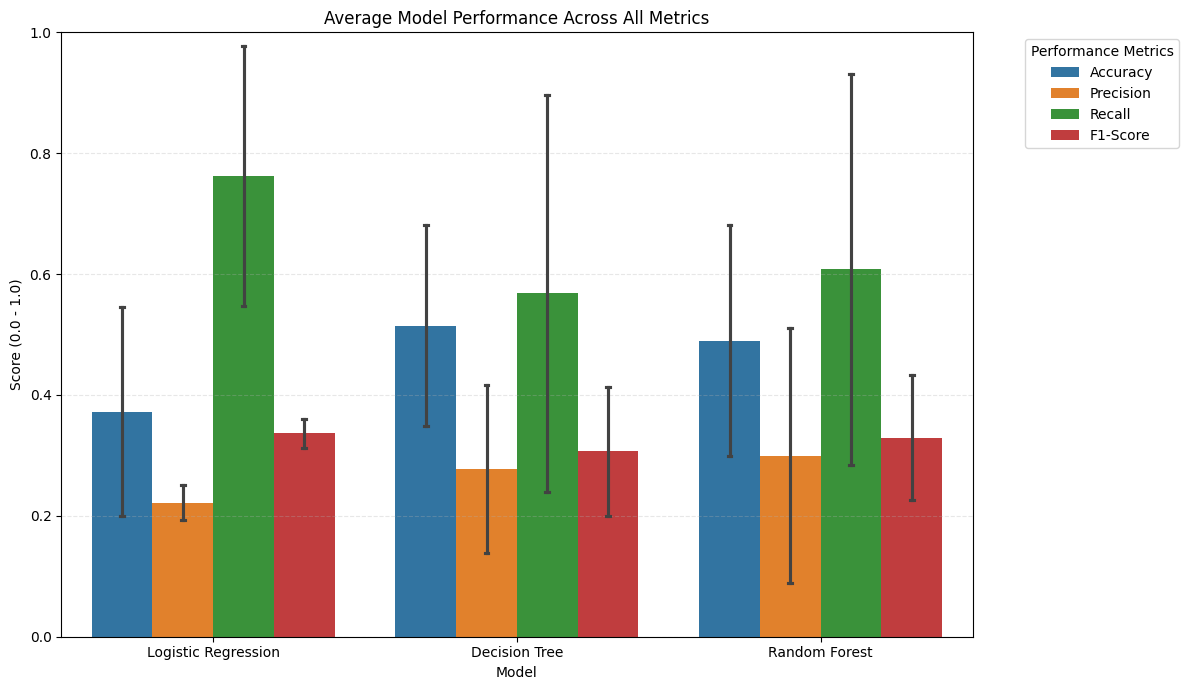

In [59]:
metrics_melted = results_df.melt(
    id_vars='Model', 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metrics_melted, 
    x="Model", 
    y="Score", 
    hue="Metric",
    capsize=.05,
    errorbar="sd"
)

plt.title("Average Model Performance Across All Metrics")
plt.ylim(0, 1.0) 
plt.ylabel("Score (0.0 - 1.0)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Performance Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

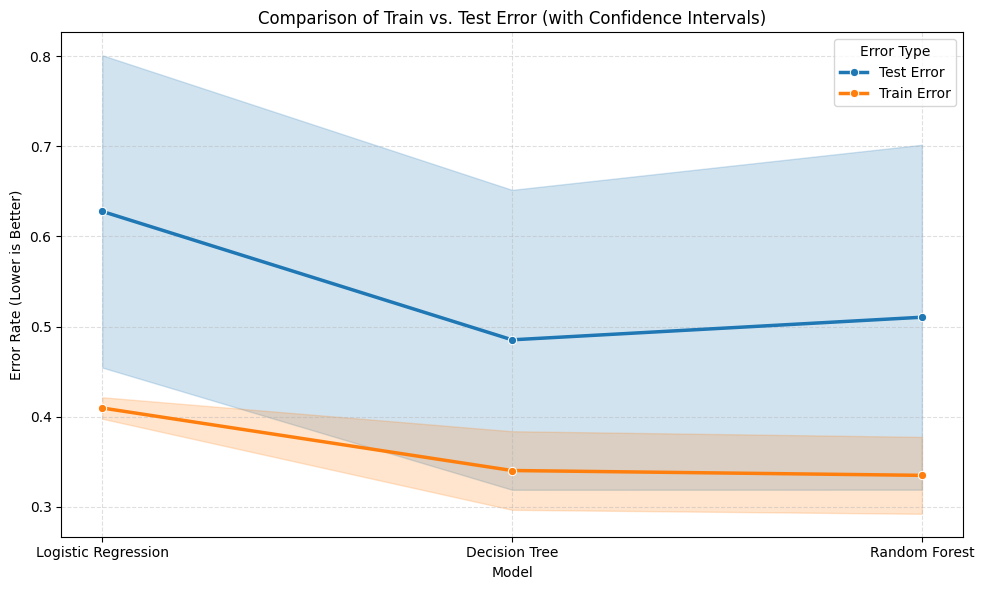

In [60]:
error_melted = results_df.melt(
    id_vars="Model", 
    value_vars=["Test Error", "Train Error"], 
    var_name="Error Type", 
    value_name="Error Rate"
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=error_melted, 
    x="Model", 
    y="Error Rate", 
    hue="Error Type", 
    marker="o", 
    linewidth=2.5,
    errorbar="sd" 
)

plt.title("Comparison of Train vs. Test Error (with Confidence Intervals)")
plt.ylabel("Error Rate (Lower is Better)")
plt.xlabel("Model")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.84      0.97      0.90     10283
           1       0.49      0.15      0.23      2191

    accuracy                           0.82     12474
   macro avg       0.67      0.56      0.56     12474
weighted avg       0.78      0.82      0.78     12474

ROC AUC: 0.6946425514400698


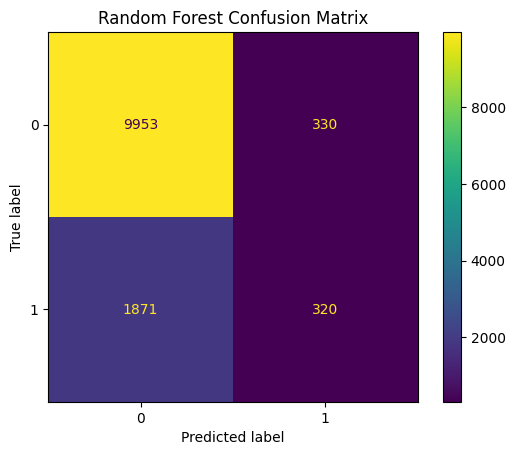

In [61]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()